# 🎯 Project Machine Learning – Object Detection (YOLO)
### Identitas Mahasiswa
### Nama: Atika Widayanti
### NIM: 231011403051
### Kelas: 05TPLP006
### Mata Kuliah: Machine Learning
### Dosen Pengampu: Hardiansyah S.Kom., M.M., M.Kom._
=================================================================================================================================================

## 1. Problem Definition

Permasalahan yang ingin diselesaikan pada proyek ini adalah deteksi objek sampah (Trash Detection) pada citra digital menggunakan metode object detection. Sampah yang tersebar di lingkungan sering kali sulit dipantau secara manual karena jumlahnya banyak dan lokasi yang beragam. Oleh karena itu, dibutuhkan sistem otomatis yang mampu mendeteksi dan mengklasifikasikan jenis sampah secara akurat.

Penelitian ini bertujuan untuk membangun model object detection berbasis YOLOv8 yang mampu mendeteksi dan mengklasifikasikan sampah ke dalam beberapa kategori, yaitu Organic, Inorganic, dan Metal, sehingga dapat membantu proses pemantauan kebersihan lingkungan dan mendukung pengelolaan sampah yang lebih efektif.

## 2. Dataset Description

- Sumber Dataset :
Dataset diperoleh dari Roboflow Universe dengan topik Trash Detection.

- Jumlah Gambar :
Total dataset terdiri dari 1.041 gambar, yang dibagi ke dalam data:

   Data training

   Data validation

- Jumlah Kelas :
Dataset memiliki 3 kelas objek sampah.

- Nama Kelas :

  Organic

  Inorganic

  Metal

- Format Dataset :

  Dataset menggunakan format YOLO, yang terdiri dari:

  Folder images untuk menyimpan gambar

  Folder labels untuk menyimpan anotasi bounding box

  File data.yaml sebagai konfigurasi dataset

# 3. Struktur Dataset YOLO

dataset/

├── train/

│   ├── images/

│   └── labels/

├── valid/

│   ├── images/

│   └── labels/

└── data.yaml


## 4. Ekstraksi Dataset

In [ ]:
!unzip "Trash Detection.v1.zip"

Archive:  Trash Detection.v1.zip
   creating: Trash Detection.v1i.yolov8/
  inflating: Trash Detection.v1i.yolov8/data.yaml  
   creating: Trash Detection.v1i.yolov8/train/
   creating: Trash Detection.v1i.yolov8/train/images/
  inflating: Trash Detection.v1i.yolov8/train/images/20230609_112358_jpg.rf.066c8a035fbcc074c6a1e018ce127f45.jpg  
  inflating: Trash Detection.v1i.yolov8/train/images/20230609_112358_jpg.rf.31ba16e931ef64572c80300dc27027f6.jpg  
  inflating: Trash Detection.v1i.yolov8/train/images/20230609_112358_jpg.rf.8b20b73ca80186100c2438d87b6ed647.jpg  
  inflating: Trash Detection.v1i.yolov8/train/images/20230609_112404_jpg.rf.7fff29a0d0276de3c18290ae47dffeb2.jpg  
  inflating: Trash Detection.v1i.yolov8/train/images/20230609_112404_jpg.rf.845c3687eb6329f8c72cb341e273d62b.jpg  
  inflating: Trash Detection.v1i.yolov8/train/images/20230609_112404_jpg.rf.c6bec0fd1ea9ac421574104c4fbbe29c.jpg  
  inflating: Trash Detection.v1i.yolov8/train/images/20230609_112425_jpg.rf.1b3bdda

## 5. Mount Google Drive

Langkah ini digunakan untuk menghubungkan Google Colab dengan Google Drive
agar file dataset, model, dan hasil eksperimen dapat disimpan secara permanen.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 6. Menampilkan File data.yaml

Langkah ini digunakan untuk menampilkan isi file `data.yaml` yang berisi
informasi konfigurasi dataset seperti lokasi data, jumlah kelas, dan nama kelas.


In [ ]:
!cat "Trash Detection.v1i.yolov8/data.yaml"

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['Inorganic', 'Metal', 'Organic']

roboflow:
  workspace: atix
  project: trash-detection-3cda1-wymwa
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/atix/trash-detection-3cda1-wymwa/dataset/1

## 7. Instalasi Library Ultralytics

Library Ultralytics digunakan untuk menjalankan algoritma YOLOv8
dalam proses training, evaluasi, dan pengujian model object detection.


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.3 MB/s eta 0:00:00


## 8. Import Library YOLO

Langkah ini dilakukan untuk mengimpor modul YOLO dari library Ultralytics
agar dapat digunakan dalam pembuatan dan pelatihan model.


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 9. Training Model YOLOv8

Pada tahap ini dilakukan pelatihan model YOLOv8 menggunakan dataset
yang telah disiapkan sebelumnya dengan parameter tertentu.


In [ ]:
model = YOLO("yolov8n.pt")

model.train(
    data="Trash Detection.v1i.yolov8/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="/content/drive/MyDrive/YOLO_Trash",
    name="exp1"
)

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Trash Detection.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=exp1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7966086eb770>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

## 10. Evaluasi Model

Evaluasi dilakukan untuk mengukur performa model menggunakan
metrik seperti mAP, precision, dan recall.


In [ ]:
metrics = model.val()

print("mAP50       :", metrics.box.map50)
print("mAP50-95    :", metrics.box.map)
print("Precision   :", metrics.box.mp)
print("Recall      :", metrics.box.mr)

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 768.7±149.9 MB/s, size: 34.4 KB)
val: Scanning /content/Trash Detection.v1i.yolov8/valid/labels.cache... 90 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 90/90 183.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.3it/s 2.6s
                   all         90        539      0.994      0.989      0.994      0.882
             Inorganic         73        176      0.994      0.994      0.994      0.869
                 Metal         52        136          1      0.991      0.995      0.927
               Organic         78        227      0.987      0.982      0.994       0.85
Speed: 4.6ms preprocess, 5.9ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to /content/runs/detect/val


## 11. Pengujian Model

Model yang telah dilatih diuji menggunakan gambar baru untuk
melihat kemampuan deteksi objek sampah secara visual.



image 1/1 /content/test.jpeg: 640x640 3 Inorganics, 2 Metals, 5 Organics, 7.3ms
Speed: 1.8ms preprocess, 7.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


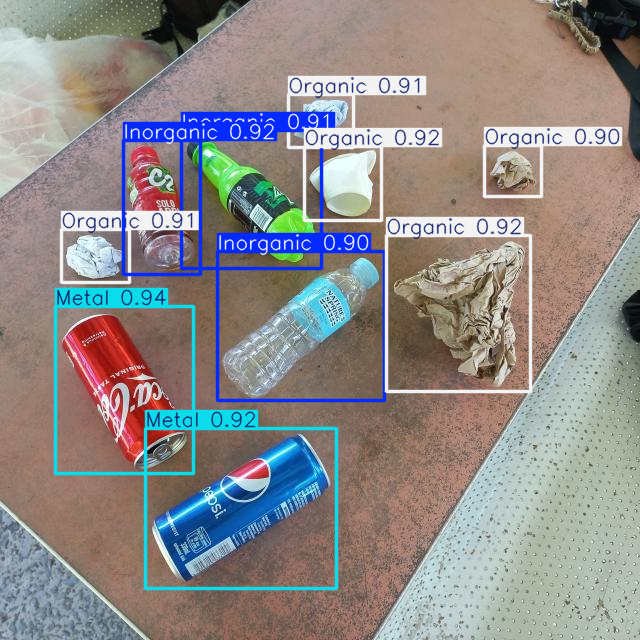

In [ ]:
results = model("test.jpeg", conf=0.3)
results[0].show()

## 12. Penyimpanan Hasil Deteksi

Hasil deteksi objek disimpan dalam bentuk file gambar
untuk keperluan dokumentasi dan pelaporan.


In [ ]:
results[0].save(filename="hasil_test.jpeg")

'hasil_test.jpeg'

# 13. Kesimpulan dan Insight

### 13.1 Hasil Utama

Berdasarkan hasil pelatihan dan evaluasi model deteksi sampah menggunakan algoritma YOLOv8, diperoleh bahwa model mampu mendeteksi objek sampah dengan baik pada tiga kelas utama, yaitu Organic, Inorganic, dan Metal. Proses training selama 50 epoch menunjukkan konvergensi model yang stabil serta performa deteksi yang cukup akurat pada data validasi dan pengujian gambar uji secara manual.

### 13.2 Kelebihan

Beberapa kelebihan dari sistem deteksi sampah yang dikembangkan adalah sebagai berikut:

Model YOLOv8 memiliki kecepatan inferensi yang tinggi sehingga cocok untuk aplikasi real-time.

Struktur dataset yang sederhana dan terorganisir memudahkan proses training dan evaluasi.

Model mampu mendeteksi beberapa objek sampah dalam satu gambar secara simultan.

Proses training dan pengujian dapat dijalankan menggunakan Google Colab tanpa memerlukan perangkat dengan spesifikasi tinggi.

### 13.3 Kekurangan

Adapun beberapa keterbatasan yang ditemukan dalam penelitian ini antara lain:

Dataset yang digunakan masih terbatas dan belum mencakup seluruh variasi kondisi lingkungan.

Tidak tersedia data uji (test dataset) terpisah sehingga evaluasi model masih bergantung pada data validasi dan pengujian manual.

Akurasi deteksi menurun pada gambar dengan pencahayaan rendah atau objek yang tertutup sebagian.

Model masih menggunakan arsitektur YOLOv8n (nano) yang memiliki jumlah parameter relatif kecil.

### 13.4 Pengembangan Lanjut

Untuk meningkatkan performa dan penerapan sistem di masa mendatang, beberapa pengembangan yang dapat dilakukan antara lain:

Menambah jumlah dan variasi dataset agar model lebih robust.

Menyediakan dataset uji terpisah untuk evaluasi performa yang lebih objektif.

Menggunakan varian YOLOv8 yang lebih besar seperti YOLOv8s atau YOLOv8m untuk meningkatkan akurasi.

Mengimplementasikan sistem deteksi ke dalam aplikasi berbasis web atau mobile.

Mengembangkan sistem deteksi secara real-time menggunakan kamera CCTV atau perangkat IoT.